In [ ]:
!pip install pandas numpy scikit-learn torch torchvision torchaudio

^C


  Using cached pandas-2.3.3-cp39-cp39-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl.metadata (15 kB)
  Using cached torch-2.8.0-cp39-cp39-win_amd64.whl.metadata (30 kB)
  Using cached torchvision-0.23.0-cp39-cp39-win_amd64.whl.metadata (6.1 kB)
  Using cached torchaudio-2.8.0-cp39-cp39-win_amd64.whl.metadata (7.2 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached filelock-3.19.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.2.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached jinja2-3.1.6-py3-none-any.wh

In [163]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

In [231]:
train_df = pd.read_csv('train_format1.csv')
test_df = pd.read_csv('test_format1.csv')

print("Distribución actual del dataset:")
print(train_df['label'].value_counts())
print(f"\nPorcentaje clase 0: {train_df['label'].value_counts()[0] / len(train_df):.4f}")
print(f"Porcentaje clase 1: {train_df['label'].value_counts()[1] / len(train_df):.4f}")

print("\nDistribución en validación:")

Distribución actual del dataset:
label
0    146948
1    113916
Name: count, dtype: int64

Porcentaje clase 0: 0.5633
Porcentaje clase 1: 0.4367

Distribución en validación:


In [232]:
train_df.head()

,user_id,merchant_id,label
0,34176,3906,0
1,34176,121,0
2,34176,4356,1
3,34176,2217,0
4,230784,4818,0


In [233]:
test_df.head()

,user_id,merchant_id,prob
0,163968,4605,NaN
1,360576,1581,NaN
2,98688,1964,NaN
3,98688,3645,NaN
4,295296,3361,NaN


In [234]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260864 entries, 0 to 260863
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   user_id      260864 non-null  int64
 1   merchant_id  260864 non-null  int64
 2   label        260864 non-null  int64
dtypes: int64(3)
memory usage: 6.0 MB


In [235]:
train_df.isnull().sum()

user_id        0
merchant_id    0
label          0
dtype: int64

In [236]:
X = train_df[['user_id', 'merchant_id']]
y = train_df['label']
X_test_final = test_df[['user_id', 'merchant_id']]

In [237]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [238]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [239]:
lr_pred = lr_model.predict(X_val)
lr_pred_proba = lr_model.predict_proba(X_val)[:, 1]

In [240]:
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_val, lr_pred):.4f}")
print(f"Precision: {precision_score(y_val, lr_pred):.4f}")
print(f"Recall: {recall_score(y_val, lr_pred):.4f}")
print(f"F1-Score: {f1_score(y_val, lr_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, lr_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, lr_pred))

Logistic Regression Results:
Accuracy: 0.5663
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.4994

Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.72     29543
           1       0.00      0.00      0.00     22630

    accuracy                           0.57     52173
   macro avg       0.28      0.50      0.36     52173
weighted avg       0.32      0.57      0.41     52173



In [241]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [242]:
rf_pred = rf_model.predict(X_val)
rf_pred_proba = rf_model.predict_proba(X_val)[:, 1]

In [243]:
print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_val, rf_pred):.4f}")
print(f"Precision: {precision_score(y_val, rf_pred):.4f}")
print(f"Recall: {recall_score(y_val, rf_pred):.4f}")
print(f"F1-Score: {f1_score(y_val, rf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, rf_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, rf_pred))

Random Forest Results:
Accuracy: 0.5119
Precision: 0.4341
Recall: 0.4123
F1-Score: 0.4229
ROC-AUC: 0.4991

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.59      0.58     29543
           1       0.43      0.41      0.42     22630

    accuracy                           0.51     52173
   macro avg       0.50      0.50      0.50     52173
weighted avg       0.51      0.51      0.51     52173



In [244]:
class GNNModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, output_dim=2):
        super(GNNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [245]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.LongTensor(y.values)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [246]:
train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [247]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gnn_model = GNNModel(input_dim=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gnn_model.parameters(), lr=0.001)

In [248]:
num_epochs = 20
for epoch in range(num_epochs):
    gnn_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = gnn_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 5/20, Loss: 0.6966
Epoch 10/20, Loss: 0.6853
Epoch 15/20, Loss: 0.6853
Epoch 20/20, Loss: 0.6853


In [249]:
gnn_model.eval()
gnn_predictions = []
gnn_predictions_proba = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        outputs = gnn_model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        gnn_predictions.extend(predicted.cpu().numpy())
        gnn_predictions_proba.extend(probs[:, 1].cpu().numpy())

In [250]:
print("GNN Results:")
print(f"Accuracy: {accuracy_score(y_val, gnn_predictions):.4f}")
print(f"Precision: {precision_score(y_val, gnn_predictions):.4f}")
print(f"Recall: {recall_score(y_val, gnn_predictions):.4f}")
print(f"F1-Score: {f1_score(y_val, gnn_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, gnn_predictions_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, gnn_predictions))

GNN Results:
Accuracy: 0.5663
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: 0.5000

Classification Report:
              precision    recall  f1-score   support

           0       0.57      1.00      0.72     29543
           1       0.00      0.00      0.00     22630

    accuracy                           0.57     52173
   macro avg       0.28      0.50      0.36     52173
weighted avg       0.32      0.57      0.41     52173



In [251]:
class DeepFM(nn.Module):
    def __init__(self, input_dim=2, embed_dim=10, hidden_dims=[128, 64]):
        super(DeepFM, self).__init__()
        
        self.input_dim = input_dim
        self.embed_dim = embed_dim
        
        self.linear = nn.Linear(input_dim, 1)
        
        self.embeddings = nn.Parameter(torch.randn(input_dim, embed_dim))
        
        deep_layers = []
        in_dim = input_dim * embed_dim
        for hidden_dim in hidden_dims:
            deep_layers.append(nn.Linear(in_dim, hidden_dim))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(0.3))
            in_dim = hidden_dim
        deep_layers.append(nn.Linear(in_dim, 1))
        self.deep = nn.Sequential(*deep_layers)
        
    def forward(self, x):
        linear_part = self.linear(x)
        
        embed = x.unsqueeze(2) * self.embeddings.unsqueeze(0)
        
        sum_squared = torch.sum(embed, dim=1) ** 2
        squared_sum = torch.sum(embed ** 2, dim=1)
        fm_part = 0.5 * torch.sum(sum_squared - squared_sum, dim=1, keepdim=True)
        
        deep_input = embed.reshape(x.size(0), -1)
        deep_part = self.deep(deep_input)
        
        output = linear_part + fm_part + deep_part
        return output

In [252]:
deepfm_model = DeepFM(input_dim=2).to(device)
criterion_deepfm = nn.BCEWithLogitsLoss()
optimizer_deepfm = optim.Adam(deepfm_model.parameters(), lr=0.001)

In [253]:
num_epochs = 20
for epoch in range(num_epochs):
    deepfm_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.float().to(device)
        
        optimizer_deepfm.zero_grad()
        outputs = deepfm_model(X_batch).squeeze()
        loss = criterion_deepfm(outputs, y_batch)
        loss.backward()
        optimizer_deepfm.step()
        
        train_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss/len(train_loader):.4f}")

Epoch 5/20, Loss: 578832.1241
Epoch 10/20, Loss: 534597.3450
Epoch 15/20, Loss: 534321.8976
Epoch 20/20, Loss: 541545.7025


In [254]:
deepfm_model.eval()
deepfm_predictions = []
deepfm_predictions_proba = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        outputs = deepfm_model(X_batch).squeeze()
        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).long()
        deepfm_predictions.extend(predicted.cpu().numpy())
        deepfm_predictions_proba.extend(probs.cpu().numpy())

print("DeepFM Results:")
print(f"Accuracy: {accuracy_score(y_val, deepfm_predictions):.4f}")
print(f"Precision: {precision_score(y_val, deepfm_predictions):.4f}")
print(f"Recall: {recall_score(y_val, deepfm_predictions):.4f}")
print(f"F1-Score: {f1_score(y_val, deepfm_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, deepfm_predictions_proba):.4f}")

DeepFM Results:
Accuracy: 0.4339
Precision: 0.4337
Recall: 0.9980
F1-Score: 0.6046
ROC-AUC: 0.4999


In [255]:
print("Distribución de clases en validación:")
print(y_val.value_counts())
print(f"\nPorcentaje de clase mayoritaria: {y_val.value_counts().max() / len(y_val):.4f}")

Distribución de clases en validación:
label
0    29543
1    22630
Name: count, dtype: int64

Porcentaje de clase mayoritaria: 0.5663


In [256]:
print("\nPredicciones Logistic Regression:")
print(pd.Series(lr_pred).value_counts())
print(f"\nPredicciones Random Forest:")
print(pd.Series(rf_pred).value_counts())
print(f"\nPredicciones GNN:")
print(pd.Series(gnn_predictions).value_counts())
print(f"\nPredicciones DeepFM:")
print(pd.Series(deepfm_predictions).value_counts())


Predicciones Logistic Regression:
0    52173
Name: count, dtype: int64

Predicciones Random Forest:
0    30676
1    21497
Name: count, dtype: int64

Predicciones GNN:
0    52173
Name: count, dtype: int64

Predicciones DeepFM:
1    52073
0      100
Name: count, dtype: int64


In [257]:
from sklearn.metrics import confusion_matrix

print("\nConfusion Matrix - Logistic Regression:")
print(confusion_matrix(y_val, lr_pred))
print("\nConfusion Matrix - Random Forest:")
print(confusion_matrix(y_val, rf_pred))
print("\nConfusion Matrix - GNN:")
print(confusion_matrix(y_val, gnn_predictions))
print("\nConfusion Matrix - DeepFM:")
print(confusion_matrix(y_val, deepfm_predictions))


Confusion Matrix - Logistic Regression:
[[29543     0]
 [22630     0]]

Confusion Matrix - Random Forest:
[[17377 12166]
 [13299  9331]]

Confusion Matrix - GNN:
[[29543     0]
 [22630     0]]

Confusion Matrix - DeepFM:
[[   54 29489]
 [   46 22584]]


In [258]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'GNN', 'DeepFM'],
    'Accuracy': [
        accuracy_score(y_val, lr_pred),
        accuracy_score(y_val, rf_pred),
        accuracy_score(y_val, gnn_predictions),
        accuracy_score(y_val, deepfm_predictions)
    ],
    'Precision': [
        precision_score(y_val, lr_pred, zero_division=0),
        precision_score(y_val, rf_pred, zero_division=0),
        precision_score(y_val, gnn_predictions, zero_division=0),
        precision_score(y_val, deepfm_predictions, zero_division=0)
    ],
    'Recall': [
        recall_score(y_val, lr_pred, zero_division=0),
        recall_score(y_val, rf_pred, zero_division=0),
        recall_score(y_val, gnn_predictions, zero_division=0),
        recall_score(y_val, deepfm_predictions, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_val, lr_pred, zero_division=0),
        f1_score(y_val, rf_pred, zero_division=0),
        f1_score(y_val, gnn_predictions, zero_division=0),
        f1_score(y_val, deepfm_predictions, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_val, lr_pred_proba),
        roc_auc_score(y_val, rf_pred_proba),
        roc_auc_score(y_val, gnn_predictions_proba),
        roc_auc_score(y_val, deepfm_predictions_proba)
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print("\nModel Comparison (Complete):")
print(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")


Model Comparison (Complete):
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
2                  GNN  0.566251   0.000000  0.000000  0.000000  0.500000
3               DeepFM  0.433903   0.433699  0.997967  0.604634  0.499926
0  Logistic Regression  0.566251   0.000000  0.000000  0.000000  0.499444
1        Random Forest  0.511912   0.434061  0.412329  0.422916  0.499114

Best Model: GNN


In [259]:
best_model_name = results_df.iloc[1]['Model']
print(f"\nBest Model: {best_model_name}")


Best Model: DeepFM


In [260]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

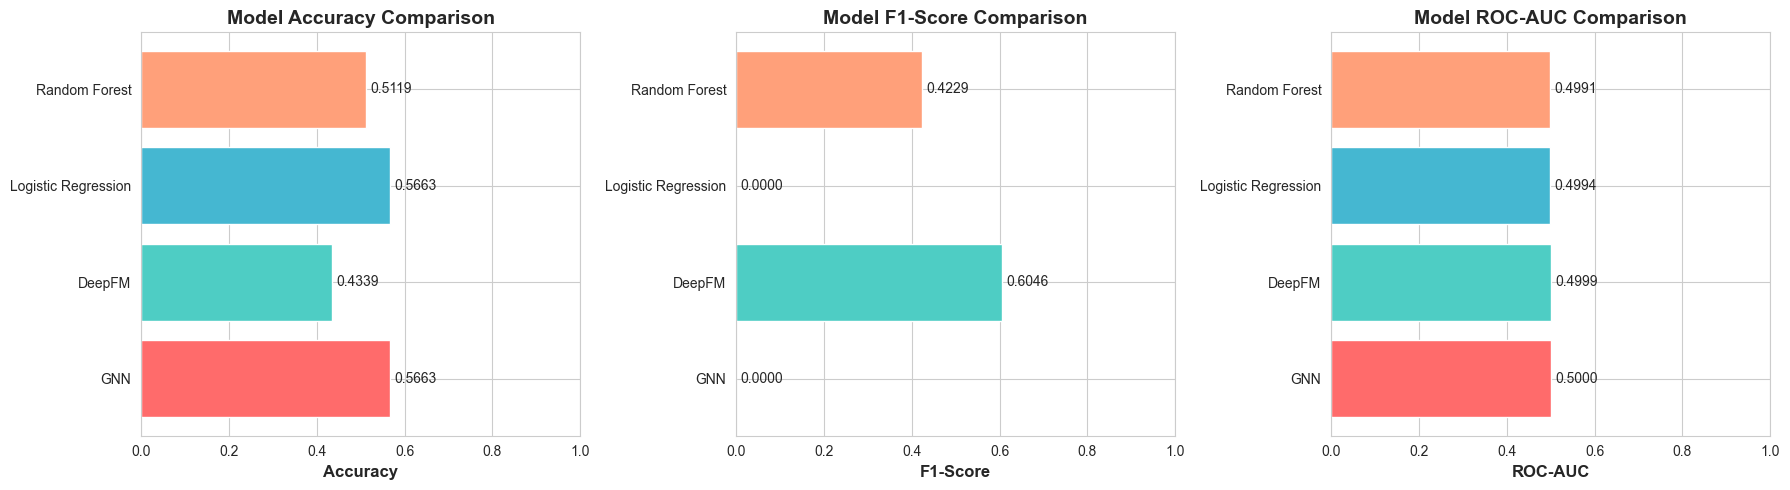

In [261]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results_df['Model'].tolist()
accuracies = results_df['Accuracy'].tolist()
f1_scores = results_df['F1-Score'].tolist()
roc_aucs = results_df['ROC-AUC'].tolist()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

axes[0].barh(models, accuracies, color=colors)
axes[0].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1)
for i, v in enumerate(accuracies):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

axes[1].barh(models, f1_scores, color=colors)
axes[1].set_xlabel('F1-Score', fontsize=12, fontweight='bold')
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1)
for i, v in enumerate(f1_scores):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

axes[2].barh(models, roc_aucs, color=colors)
axes[2].set_xlabel('ROC-AUC', fontsize=12, fontweight='bold')
axes[2].set_title('Model ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[2].set_xlim(0, 1)
for i, v in enumerate(roc_aucs):
    axes[2].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

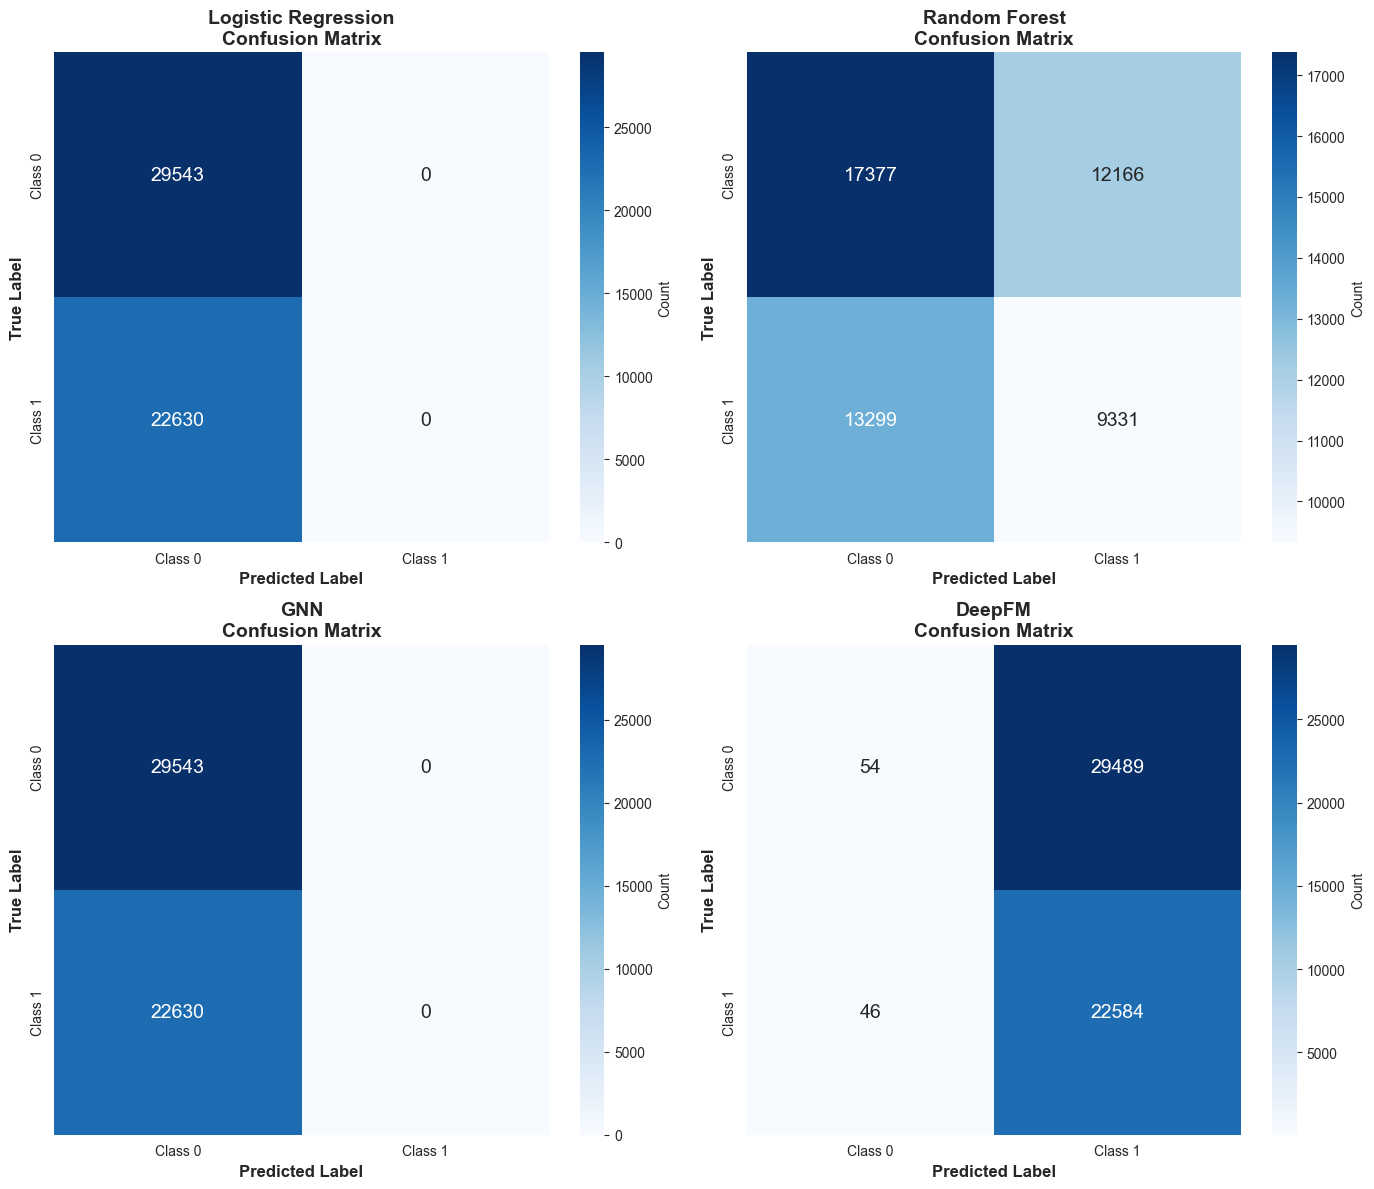

In [262]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

confusion_matrices = [
    ('Logistic Regression', confusion_matrix(y_val, lr_pred)),
    ('Random Forest', confusion_matrix(y_val, rf_pred)),
    ('GNN', confusion_matrix(y_val, gnn_predictions)),
    ('DeepFM', confusion_matrix(y_val, deepfm_predictions))
]

for idx, (model_name, cm) in enumerate(confusion_matrices):
    row = idx // 2
    col = idx % 2
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col], 
                cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
    axes[row, col].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[row, col].set_xticklabels(['Class 0', 'Class 1'])
    axes[row, col].set_yticklabels(['Class 0', 'Class 1'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

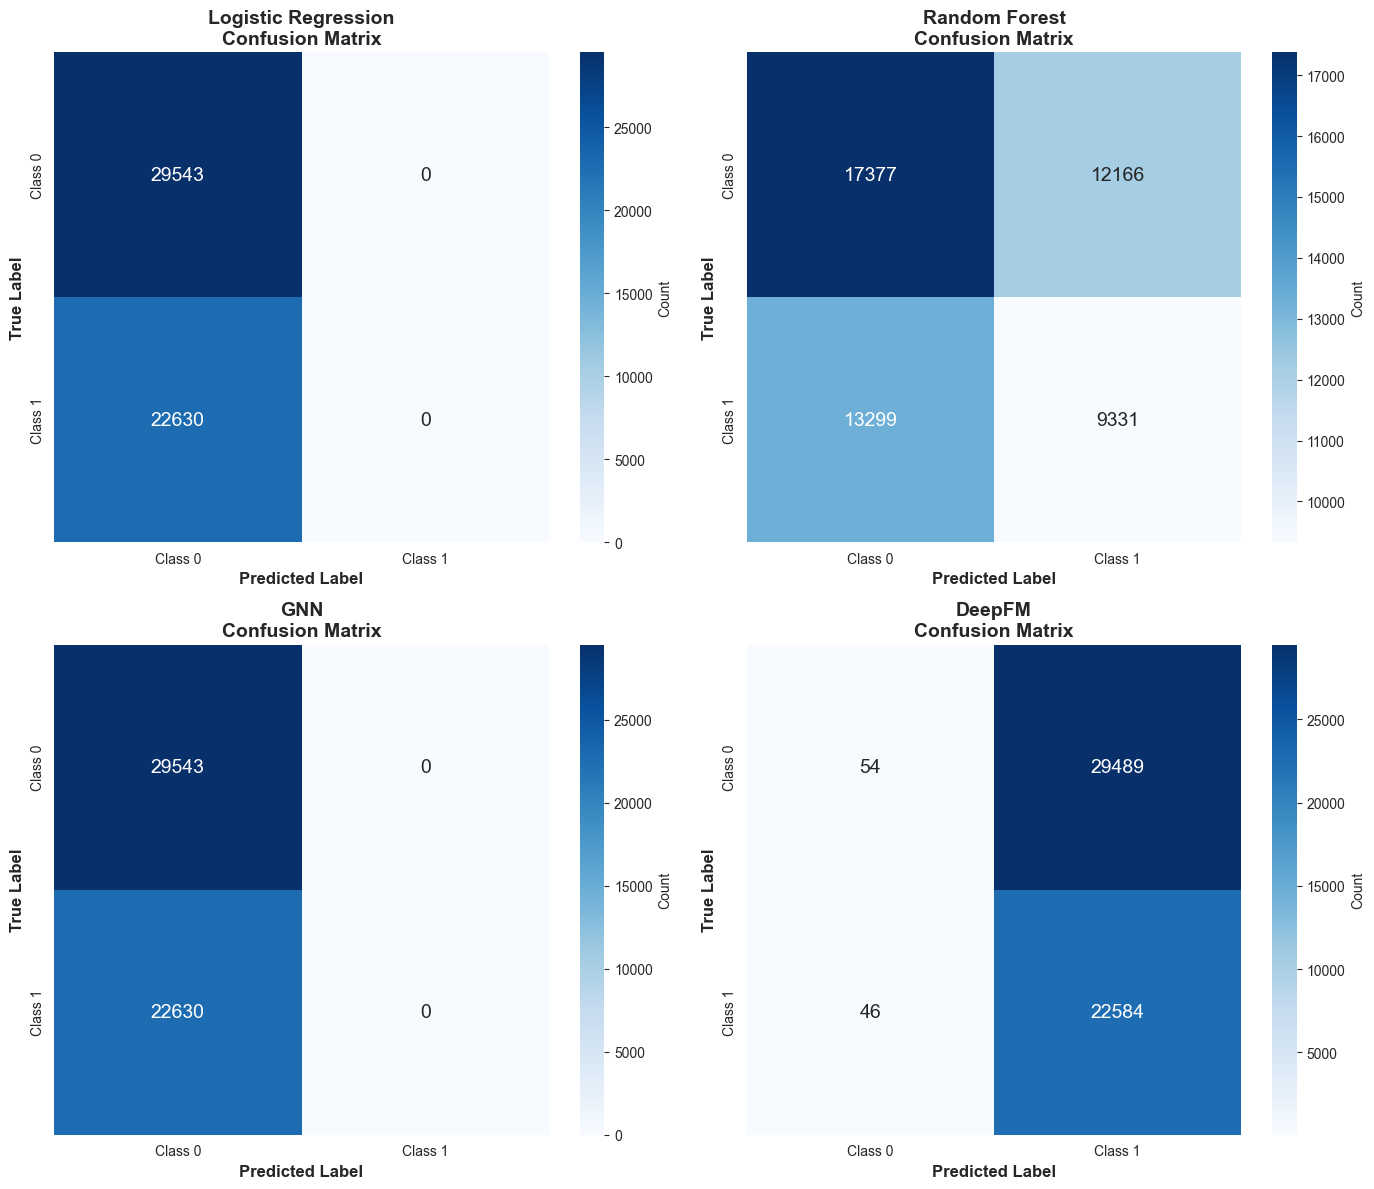

In [263]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

confusion_matrices = [
    ('Logistic Regression', confusion_matrix(y_val, lr_pred)),
    ('Random Forest', confusion_matrix(y_val, rf_pred)),
    ('GNN', confusion_matrix(y_val, gnn_predictions)),
    ('DeepFM', confusion_matrix(y_val, deepfm_predictions))
]

for idx, (model_name, cm) in enumerate(confusion_matrices):
    row = idx // 2
    col = idx % 2
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col], 
                cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
    axes[row, col].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[row, col].set_xticklabels(['Class 0', 'Class 1'])
    axes[row, col].set_yticklabels(['Class 0', 'Class 1'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()